# Data Collection

In [1]:
!pip install praw


   -------------------------- ------------- 2/3 [praw]
   -------------------------- ------------- 2/3 [praw]
   ---------------------------------------- 3/3 [praw]



In [2]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import os
import praw

In [3]:
reddit = praw.Reddit(
   client_id = 'LIHrG7zHDL0mJPXjHnW1Ng',
   client_secret = 'SDR21LCAysSKiThxEhCmur4FmXjGRQ',
   user_agent = "reddit-data-analysis:v1.0 (by u/angel0980130)"
)

In [7]:
# hot-year-sub=all --> get subreddits

subreddit = reddit.subreddit('all')

hot_year_all = []

for i, post in enumerate(subreddit.search('"iPhone 17"', sort="hot", time_filter="year", limit=300)):
    hot_year_all.append({
        "title": post.title,
        "author": str(post.author),
        "created": datetime.utcfromtimestamp(post.created_utc),
        "num_comments": post.num_comments,
        "subreddit": str(post.subreddit),
        "score": post.score,
        "text": post.selftext,
    })

    if (i + 1) % 100 == 0:
        time.sleep(1)
        
hot_year_all_df = pd.DataFrame(hot_year_all)
print("total posts:", len(hot_year_all_df))

hot_year_all_df.sort_values("created", ascending=False, inplace=True)
hot_year_all_df.reset_index(drop=True, inplace=True)

hot_year_all_df

C:\Users\sruth\AppData\Local\Temp\ipykernel_15416\2742106945.py:11: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "created": datetime.utcfromtimestamp(post.created_utc),


total posts: 250


,title,author,created,num_comments,subreddit,score,text
0,ONEPLUS 15 has the highest Multi-Core Score of...,Shoddy-District-1850,2025-12-03 17:37:01,1,Oneplusfans,3,
1,What song is blasting out this new iPhone 17?,kuntbitcchnigfers,2025-12-03 17:24:11,10,songsforthispicture,6,
2,Win an iPhone 17 in our Christmas giveaway! (1...,Selector28,2025-12-03 17:22:39,1,giveawaysforgaming,2,
3,ONEPLUS 15 has the highest Multi-Core Score of...,HamedAliKhan,2025-12-03 17:18:09,7,oneplus15,5,
4,Testing iPhone 17 camera,Key_Can_7248,2025-12-03 17:14:56,2,iPhoneWale,15,stock camera no post edit
...,...,...,...,...,...,...,...
245,Iphone 17 mini?,Background_Time_3556,2025-11-26 15:49:21,2,Iphone_17_mini,4,its a model and i have sent the design to tim ...
246,Iphone 17 battery,hisBoAt69,2025-11-26 12:51:42,3,applehelp,2,Is this normal for iphone17 6 days old battery...
247,Should I buy the iPhone 17?,Classic_Blossom,2025-11-26 12:06:03,20,iPhone11,7,I currently have the 11 base 64gb but I am str...
248,iPhone 17 upgrade advice,orenkatz_,2025-11-25 22:30:04,15,iPhone17Pro,2,"Coming from a 14 Pro with 83% battery, heat, a..."


Text(0.5, 1.0, 'Subreddits Mentioning iPhone 17 More Than 5 Times NEW')

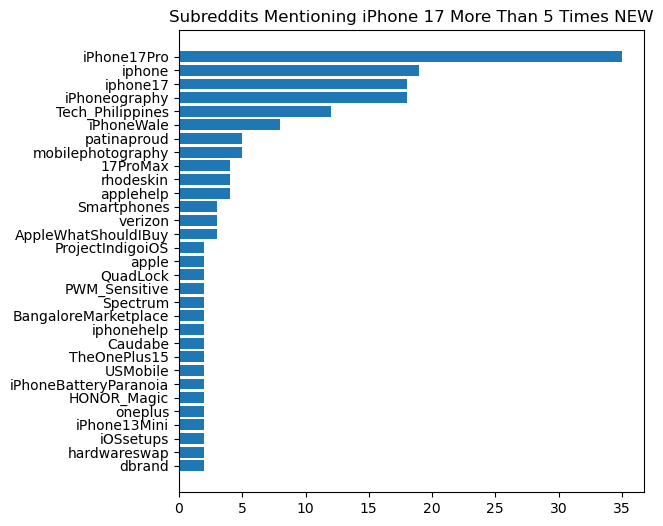

In [8]:
#choose subreddits
subreddit_ranking_new = hot_year_all_df.groupby('subreddit').size().sort_values(ascending=False)

plt.figure(figsize=(6, 6))
plt.barh(subreddit_ranking_new[subreddit_ranking_new >= 2].index, subreddit_ranking_new[subreddit_ranking_new >= 2].values)
plt.gca().invert_yaxis()
plt.title('Subreddits Mentioning iPhone 17 More Than 5 Times NEW')

# #get list of subreddits
# # subreddits_new = subreddit_ranking[subreddit_ranking >= 5].index.tolist()

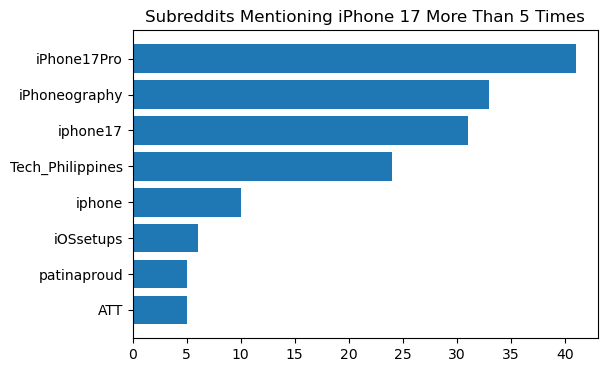

In [56]:
#choose subreddits
subreddit_ranking = hot_year_all_df.groupby('subreddit').size().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.barh(subreddit_ranking[subreddit_ranking >= 5].index, subreddit_ranking[subreddit_ranking >= 5].values)
plt.gca().invert_yaxis()
plt.title('Subreddits Mentioning iPhone 17 More Than 5 Times')

#get list of subreddits
subreddits = subreddit_ranking[subreddit_ranking >= 5].index.tolist()

In [9]:
subreddits = ['iPhone17Pro', 'iPhoneography', 'iphone17', 'iphone', 'iOSsetups', 'patinaproud', 'ATT']

In [10]:
# hot-year-sub(for loop)

hot_year_subs = []

for sub in subreddits:

    for i, post in enumerate(reddit.subreddit(sub).search('"iPhone 17"', sort="hot", time_filter="year", limit=300)):
        hot_year_subs.append({
            "title": post.title,
            "author": str(post.author),
            "created": datetime.utcfromtimestamp(post.created_utc),
            "num_comments": post.num_comments,
            "subreddit": str(post.subreddit),
            "score": post.score,
            "text": post.selftext,
        })

        if (i + 1) % 100 == 0:
            time.sleep(1)
        
hot_year_subs_df = pd.DataFrame(hot_year_subs)
print("total posts:", len(hot_year_subs_df))

hot_year_subs_df.sort_values("created", ascending=False, inplace=True)
hot_year_subs_df.reset_index(drop=True, inplace=True)

hot_year_subs_df.head()

total posts: 1298


,title,author,created,num_comments,subreddit,score,text
0,Foggy Morning in Paris,Le-Croissant,2025-11-18 20:34:07,3,iPhoneography,37,
1,Ryan London leather case iPhone 17 PM open bot...,bjayernaeiy,2025-11-18 20:13:14,0,patinaproud,2,"Hi, My iPhone 17 Pro Max arrived and I want to..."
2,Does anyone know if a iphone 17 or pro max fro...,Front_Laugh_8595,2025-11-18 19:13:47,4,iphone,4,Why did apple make usa esim only
3,TechWoven Case Bubble Sides,oguzhancet,2025-11-18 17:56:45,1,iphone,2,I’ve been using the Apple TechWoven Case for m...
4,Is there iPhone 17 pro leather cases with full...,BannedRedditIPO,2025-11-18 16:04:33,11,patinaproud,6,Sorry this isn't a photo of an iPhone case or ...


In [11]:
hot_year_subs_df.tail(15)

,title,author,created,num_comments,subreddit,score,text
1283,ATT Next Up Anytime New iPhone,Akorm6,2025-09-09 20:21:03,29,ATT,8,I am confused on these 2 options and what ATT ...
1284,iPhone 17 Pro Max Cases,damo74uk,2025-09-05 21:14:51,9,patinaproud,4,If the rumoured orange phone gets announced ne...
1285,Do you think they’ll do the 1000 trade in at i...,Ajseps,2025-08-27 15:48:52,65,ATT,10,Want to trade in my 14 pro max and get the 100...
1286,Thinking about making a leather case with a bu...,BlackBrook_Official,2025-08-21 19:39:38,18,patinaproud,24,We’ve been experimenting with a case design th...
1287,Advice on Iphone 12 pro max Trade in,SectionLive4152,2025-08-21 13:53:23,8,ATT,2,"Hello, \n\nI was a dummy and missed the $830 t..."
1288,What I’m rocking right now,justinpham1337,2025-08-18 05:42:46,4,iOSsetups,13,
1289,This wallpaper please,mohamed_edge,2025-08-17 20:27:34,4,iOSsetups,2,
1290,Leather iPhone 17 Cases,BlackBrook_Official,2025-08-17 15:29:49,52,patinaproud,53,We’re getting our leather cases ready for the ...
1291,Noticed these on the Andar website.,little_kid_lover3120,2025-08-15 02:18:48,4,patinaproud,27,
1292,Rate my setup 🫧,Lroogie_R,2025-08-13 12:10:09,9,iOSsetups,40,I like light and dark matches. For wallpaper l...


In [12]:
# top-year-sub(for loop)
top_year_subs = []

for sub in subreddits:

    for i, post in enumerate(reddit.subreddit(sub).search('"iPhone 17"', sort="top", time_filter="year", limit=300)):
        top_year_subs.append({
            "title": post.title,
            "author": str(post.author),
            "created": datetime.utcfromtimestamp(post.created_utc),
            "num_comments": post.num_comments,
            "subreddit": str(post.subreddit),
            "score": post.score,
            "text": post.selftext,
        })

        if (i + 1) % 100 == 0:
            time.sleep(1)
        
top_year_subs_df = pd.DataFrame(top_year_subs)
print("total posts:", len(top_year_subs_df))

top_year_subs_df.sort_values("created", ascending=False, inplace=True)
top_year_subs_df.reset_index(drop=True, inplace=True)

top_year_subs_df.head()

total posts: 1370


,title,author,created,num_comments,subreddit,score,text
0,Foggy Morning in Paris,Le-Croissant,2025-11-18 20:34:07,3,iPhoneography,38,
1,Ryan London leather case iPhone 17 PM open bot...,bjayernaeiy,2025-11-18 20:13:14,0,patinaproud,2,"Hi, My iPhone 17 Pro Max arrived and I want to..."
2,Is there iPhone 17 pro leather cases with full...,BannedRedditIPO,2025-11-18 16:04:33,11,patinaproud,6,Sorry this isn't a photo of an iPhone case or ...
3,Will the powerbank made for iphone air work on...,quiet-panda-360,2025-11-18 15:12:31,125,iphone,544,I have the original apple magsafe battery and ...
4,From iPhone 11 (Product Red) to Iphone 17 Sage,Tibanga,2025-11-18 13:31:44,5,iphone17,17,Starter pack 🤪


In [13]:
top_year_subs_df.tail(15)

,title,author,created,num_comments,subreddit,score,text
1355,"iPhone 17 Pro Said to Feature 12GB of RAM, 48-...",Fer65432_Plays,2025-03-18 15:15:25,118,iphone,642,
1356,'iPhone 17 Air' Rumored to Start at $899 With ...,PJ09,2025-03-17 07:03:14,8,iphone17,15,
1357,iPhone 17 series dummy models leaked,Embarrassed-Carry507,2025-03-16 11:05:24,1717,iphone,8489,What are we thinking?
1358,At least one iPhone 17 model to get liquid coo...,Fer65432_Plays,2025-03-12 13:07:25,40,iphone,467,
1359,Latest iPhone 17 Series CAD Images,FitDiscussion4,2025-02-28 11:14:49,62,iphone,59,
1360,Wild theory about the back of iPhone 17,Photoro,2025-02-24 23:46:36,24,iphone,50,"I was playing with my iPhone recently, and I n..."
1361,Kuo: All iPhone 17 Models Will Feature Apple-D...,Fer65432_Plays,2025-02-20 20:55:11,30,iphone,219,
1362,Can’t decide if I should trade in my iPhone 14...,Positive_Bluebird370,2025-02-20 01:07:55,14,ATT,2,I currently have the iPhone 14 and i’m eligibl...
1363,Wireless reverse charging being tested in the ...,Fer65432_Plays,2025-02-19 13:26:19,33,iphone,104,
1364,iPhone 17 Lineup Rumored to Support Up to 35W ...,Fer65432_Plays,2025-02-18 23:25:17,74,iphone,347,


In [14]:
# top-month-sub(for loop)
top_month_subs = []

for sub in subreddits:

    for i, post in enumerate(reddit.subreddit(sub).search('"iPhone 17"', sort="top", time_filter="month", limit=300)):
        top_month_subs.append({
            "title": post.title,
            "author": str(post.author),
            "created": datetime.utcfromtimestamp(post.created_utc),
            "num_comments": post.num_comments,
            "subreddit": str(post.subreddit),
            "score": post.score,
            "text": post.selftext,
        })

        if (i + 1) % 100 == 0:
            time.sleep(1)
        
top_month_subs_df = pd.DataFrame(top_month_subs)
print("total posts:", len(top_month_subs_df))

top_month_subs_df.sort_values("created", ascending=False, inplace=True)
top_month_subs_df.reset_index(drop=True, inplace=True)

top_month_subs_df.head()

total posts: 1143


,title,author,created,num_comments,subreddit,score,text
0,Foggy Morning in Paris,Le-Croissant,2025-11-18 20:34:07,3,iPhoneography,38,
1,Ryan London leather case iPhone 17 PM open bot...,bjayernaeiy,2025-11-18 20:13:14,0,patinaproud,2,"Hi, My iPhone 17 Pro Max arrived and I want to..."
2,Aftermarket alternative to finewoven for iPhon...,Towelie_SE,2025-11-18 19:50:41,0,iphone,1,I'm probably one of the few who really like fi...
3,Does anyone know if a iphone 17 or pro max fro...,Front_Laugh_8595,2025-11-18 19:13:47,4,iphone,5,Why did apple make usa esim only
4,TechWoven Case Bubble Sides,oguzhancet,2025-11-18 17:56:45,1,iphone,2,I’ve been using the Apple TechWoven Case for m...


In [15]:
# relevance-year-sub(for loop)
relevance_year_subs = []

for sub in subreddits:

    for i, post in enumerate(reddit.subreddit(sub).search('"iPhone 17"', sort="relevance", time_filter="year", limit=300)):
        relevance_year_subs.append({
            "title": post.title,
            "author": str(post.author),
            "created": datetime.utcfromtimestamp(post.created_utc),
            "num_comments": post.num_comments,
            "subreddit": str(post.subreddit),
            "score": post.score,
            "text": post.selftext,
        })

        if (i + 1) % 100 == 0:
            time.sleep(1)
        
relevance_year_subs_df = pd.DataFrame(relevance_year_subs)
print("total posts:", len(relevance_year_subs_df))

relevance_year_subs_df.sort_values("created", ascending=False, inplace=True)
relevance_year_subs_df.reset_index(drop=True, inplace=True)

relevance_year_subs_df.head()

total posts: 1372


,title,author,created,num_comments,subreddit,score,text
0,Ryan London leather case iPhone 17 PM open bot...,bjayernaeiy,2025-11-18 20:13:14,0,patinaproud,2,"Hi, My iPhone 17 Pro Max arrived and I want to..."
1,Is there iPhone 17 pro leather cases with full...,BannedRedditIPO,2025-11-18 16:04:33,11,patinaproud,6,Sorry this isn't a photo of an iPhone case or ...
2,Dust in the front mirror of the iPhone 17 pro.,Inevitable_Let_2674,2025-11-18 15:59:58,17,iPhone17Pro,0,"Hi, a few days ago I purchased an iPhone 17 pr..."
3,getting the iPhone 17 pro max SERIOUS CHOICE,Nxtro69,2025-11-18 15:51:35,19,iPhone17Pro,0,516gb or 1TB LIKE IM STUCK ON IT please convin...
4,Will the powerbank made for iphone air work on...,quiet-panda-360,2025-11-18 15:12:31,125,iphone,543,I have the original apple magsafe battery and ...


In [16]:
relevance_year_subs_df.tail(15)

,title,author,created,num_comments,subreddit,score,text
1357,Report: Apple cancels iPhone 17 Pro's new anti...,nimicdoareu,2025-04-29 15:31:56,113,iphone,336,
1358,iPhone 17 series new rumors,Sure_Concert6963,2025-04-23 17:30:09,478,iphone,705,Me personally I think I won't like the new des...
1359,"Here's how thin the iPhone 17 Air is, in-hand",nimicdoareu,2025-04-23 07:48:49,183,iphone,380,
1360,"iPhone 17 Pro Max - The ""Ultimate"" iPhone of t...",_Nexus8_,2025-04-10 19:52:16,97,iphone,55,Been thinking about this for a while and wante...
1361,iPhone 17 pro case render,querythoughtss,2025-03-27 20:08:08,61,iphone,235,
1362,iPhone 17 Pro's Potential 8K Video Recording C...,DAVIDBRAZIL18,2025-03-27 12:58:55,103,iphone,351,"A Chinese leaker, Fixed Focus Digital, suggest..."
1363,iphone 17 pro max will have a new back design,Delicious_Room_814,2025-03-25 17:44:51,94,iphone,360,
1364,Who wants to see this charging feature on the ...,Ayts96,2025-03-22 16:20:38,102,iphone,262,
1365,Rumored iPhone 17 air specs,phototech_bird1533,2025-03-20 20:38:13,212,iphone,171,
1366,"iPhone 17 Pro Said to Feature 12GB of RAM, 48-...",Fer65432_Plays,2025-03-18 15:15:25,118,iphone,639,


In [17]:
# relevance-month-sub(for loop)
relevance_month_subs = []

for sub in subreddits:

    for i, post in enumerate(reddit.subreddit(sub).search('"iPhone 17"', sort="relevance", time_filter="month", limit=300)):
        relevance_month_subs.append({
            "title": post.title,
            "author": str(post.author),
            "created": datetime.utcfromtimestamp(post.created_utc),
            "num_comments": post.num_comments,
            "subreddit": str(post.subreddit),
            "score": post.score,
            "text": post.selftext,
        })

        if (i + 1) % 100 == 0:
            time.sleep(1)
        
relevance_month_subs_df = pd.DataFrame(relevance_month_subs)
print("total posts:", len(relevance_month_subs_df))

relevance_month_subs_df.sort_values("created", ascending=False, inplace=True)
relevance_month_subs_df.reset_index(drop=True, inplace=True)

relevance_month_subs_df.head()

total posts: 1139


,title,author,created,num_comments,subreddit,score,text
0,Foggy Morning in Paris,Le-Croissant,2025-11-18 20:34:07,3,iPhoneography,38,
1,Ryan London leather case iPhone 17 PM open bot...,bjayernaeiy,2025-11-18 20:13:14,0,patinaproud,2,"Hi, My iPhone 17 Pro Max arrived and I want to..."
2,Does anyone know if a iphone 17 or pro max fro...,Front_Laugh_8595,2025-11-18 19:13:47,4,iphone,3,Why did apple make usa esim only
3,Whats wrong with the Iphone 17 camera?,hotttogo_,2025-11-18 17:40:33,19,iphone,0,I recently got the iPhone 17 Pro for the camer...
4,Is there iPhone 17 pro leather cases with full...,BannedRedditIPO,2025-11-18 16:04:33,11,patinaproud,6,Sorry this isn't a photo of an iPhone case or ...


In [18]:
# concat datasets + sort + remove duplicates & empty text

all_datasets = [hot_year_subs_df, top_year_subs_df, top_month_subs_df, relevance_year_subs_df, relevance_month_subs_df]

#concat
all_df = pd.concat(all_datasets, ignore_index=True)

#sort
all_df.sort_values("created", ascending=False, inplace=True)

#remove duplicates
all_df = all_df.drop_duplicates(subset=['title', 'author'], keep='first')
all_df

#remove empty text
all_df = all_df[all_df['text'].notna() & (all_df['text'].str.strip() != '')]
all_df = all_df.reset_index(drop=True)

all_df

,title,author,created,num_comments,subreddit,score,text
0,Ryan London leather case iPhone 17 PM open bot...,bjayernaeiy,2025-11-18 20:13:14,0,patinaproud,2,"Hi, My iPhone 17 Pro Max arrived and I want to..."
1,Aftermarket alternative to finewoven for iPhon...,Towelie_SE,2025-11-18 19:50:41,0,iphone,1,I'm probably one of the few who really like fi...
2,Does anyone know if a iphone 17 or pro max fro...,Front_Laugh_8595,2025-11-18 19:13:47,4,iphone,5,Why did apple make usa esim only
3,TechWoven Case Bubble Sides,oguzhancet,2025-11-18 17:56:45,1,iphone,2,I’ve been using the Apple TechWoven Case for m...
4,Whats wrong with the Iphone 17 camera?,hotttogo_,2025-11-18 17:40:33,19,iphone,0,I recently got the iPhone 17 Pro for the camer...
...,...,...,...,...,...,...,...
2229,iPhone 17 series dummy models leaked,Embarrassed-Carry507,2025-03-16 11:05:24,1717,iphone,8482,What are we thinking?
2230,Wild theory about the back of iPhone 17,Photoro,2025-02-24 23:46:36,24,iphone,50,"I was playing with my iPhone recently, and I n..."
2231,Can’t decide if I should trade in my iPhone 14...,Positive_Bluebird370,2025-02-20 01:07:55,14,ATT,2,I currently have the iPhone 14 and i’m eligibl...
2232,What’s new in iOS 18.3 for non Apple intellige...,Stargazer857,2025-01-28 05:03:20,69,iphone,191,The only change I saw on my phone after iOS up...


In [19]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

analyzer = SentimentIntensityAnalyzer()

# add sentiment score column
all_df["sentiment"] = all_df["text"].apply(lambda x: analyzer.polarity_scores(x)["compound"])

# tag positive or negative based on sentiment score
all_df["sentiment_label"] = all_df["sentiment"].apply(
    lambda x: "positive" if x > 0.05 else ("negative" if x < -0.05 else "neutral")
)

all_df.head()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,title,author,created,num_comments,subreddit,score,text,sentiment,sentiment_label
0,Ryan London leather case iPhone 17 PM open bot...,bjayernaeiy,2025-11-18 20:13:14,0,patinaproud,2,"Hi, My iPhone 17 Pro Max arrived and I want to...",0.6597,positive
1,Aftermarket alternative to finewoven for iPhon...,Towelie_SE,2025-11-18 19:50:41,0,iphone,1,I'm probably one of the few who really like fi...,-0.8195,negative
2,Does anyone know if a iphone 17 or pro max fro...,Front_Laugh_8595,2025-11-18 19:13:47,4,iphone,5,Why did apple make usa esim only,0.0000,neutral
3,TechWoven Case Bubble Sides,oguzhancet,2025-11-18 17:56:45,1,iphone,2,I’ve been using the Apple TechWoven Case for m...,-0.8979,negative
4,Whats wrong with the Iphone 17 camera?,hotttogo_,2025-11-18 17:40:33,19,iphone,0,I recently got the iPhone 17 Pro for the camer...,0.5080,positive


In [20]:
# download dataset

all_df.to_csv("reddit_iphone17_sentiment_1118_v1.csv", index=False, encoding="utf-8-sig")
print("✅ output：reddit_iphone17_sentiment_1118_v1.csv")

✅ output：reddit_iphone17_sentiment_1118_v1.csv


# ANALYSIS:

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud, STOPWORDS
import re

In [30]:
# Import file
df = pd.read_excel('reddit_iphone17_sentiment_1103+1118 (1).xlsx') #Cleaned file

# text columns to strings
df["title"] = df["title"].fillna("").astype(str)
df["text"]  = df["text"].fillna("").astype(str)

# Combine into one text field for modeling
df["full_text"] = df["title"] + " " + df["text"]
DATE_COL = "created"
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# EDA

Number of Posts by Sentiment:
033 sentiment_label
positive    1634
negative     543
neutral      432
Name: count, dtype: int64


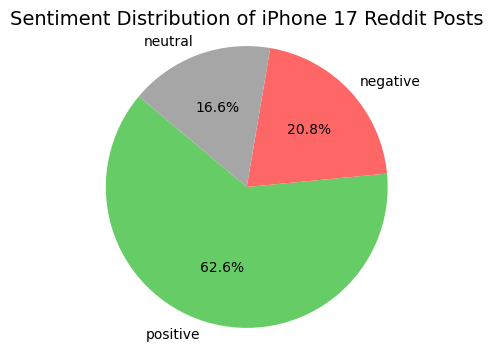

In [31]:
# Count sentiment categories
sent_counts = df["sentiment_label"].value_counts()
print('\033[1mNumber of Posts by Sentiment:\n033[0m',sent_counts)

color_map = {
    "positive": "#66cc66",  # darker green
    "negative": "#ff6666",  # darker red
    "neutral":  "#a6a6a6"   # soft neutral grey
}
sent_order = ["positive", "negative", "neutral"]
sent_counts = sent_counts.reindex(sent_order)
colors = [color_map[s] for s in sent_order]

# Pie chart
plt.figure(figsize=(4, 4))
plt.pie(
    sent_counts.values,
    labels=sent_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors
)

plt.title("Sentiment Distribution of iPhone 17 Reddit Posts", fontsize=14)
plt.axis("equal")
plt.show()


## Percentage of Engagement for each sentiment

                 num_posts  total_score  engagement_pct
sentiment_label                                        
positive              1634       125395           57.83
neutral                432        81288           25.46
negative               543        29817           16.71


C:\Users\sruth\AppData\Local\Temp\ipykernel_36960\249962653.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


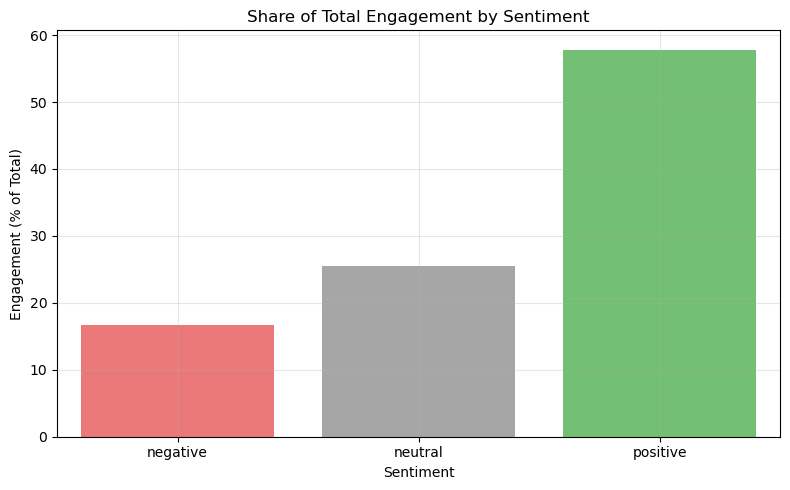

In [32]:
sentiment_metrics = (
    df.groupby("sentiment_label")
      .agg(
          num_posts=("full_text", "size"),
          total_score=("score", "sum")
      )
)

# Totals
total_posts = sentiment_metrics["num_posts"].sum()
total_score = sentiment_metrics["total_score"].sum()

# Engagement computation
sentiment_metrics["posts_share"] = sentiment_metrics["num_posts"] / total_posts
sentiment_metrics["score_share"] = sentiment_metrics["total_score"] / total_score

sentiment_metrics["engagement_norm"] = (
    sentiment_metrics["posts_share"] +
    sentiment_metrics["score_share"]
)

sentiment_metrics["engagement_pct"] = (
    sentiment_metrics["engagement_norm"] /
    sentiment_metrics["engagement_norm"].sum() * 100
)

print(
    sentiment_metrics[["num_posts", "total_score", "engagement_pct"]]
    .sort_values("engagement_pct", ascending=False)
    .round(2)
)
color_map = {
    "positive": "#66cc66",  # darker green
    "negative": "#ff6666",  # darker red
    "neutral":  "#a6a6a6"   # soft neutral grey
}
# Visualization
sent_plot = sentiment_metrics.reset_index()
sent_plot["color"] = sent_plot["sentiment_label"].map(color_map)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=sent_plot,
    x="sentiment_label",
    y="engagement_pct",
    palette=sent_plot["color"].tolist()
)

plt.title("Share of Total Engagement by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Engagement (% of Total)")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [33]:
neg_df = df[df["sentiment_label"] == "negative"].copy()
neg_df = neg_df.dropna(subset=["full_text", "subreddit"])
print("Negative posts:", len(neg_df))

pos_df = df[df["sentiment_label"] == "positive"].copy()
pos_df = pos_df.dropna(subset=["full_text", "subreddit"])
print("Positive posts:", len(pos_df))


Negative posts: 543
Positive posts: 1634


## Average Engagement over time for Positive, Negative and Neutral

First date in dataset: 2025-09-03 20:37:00


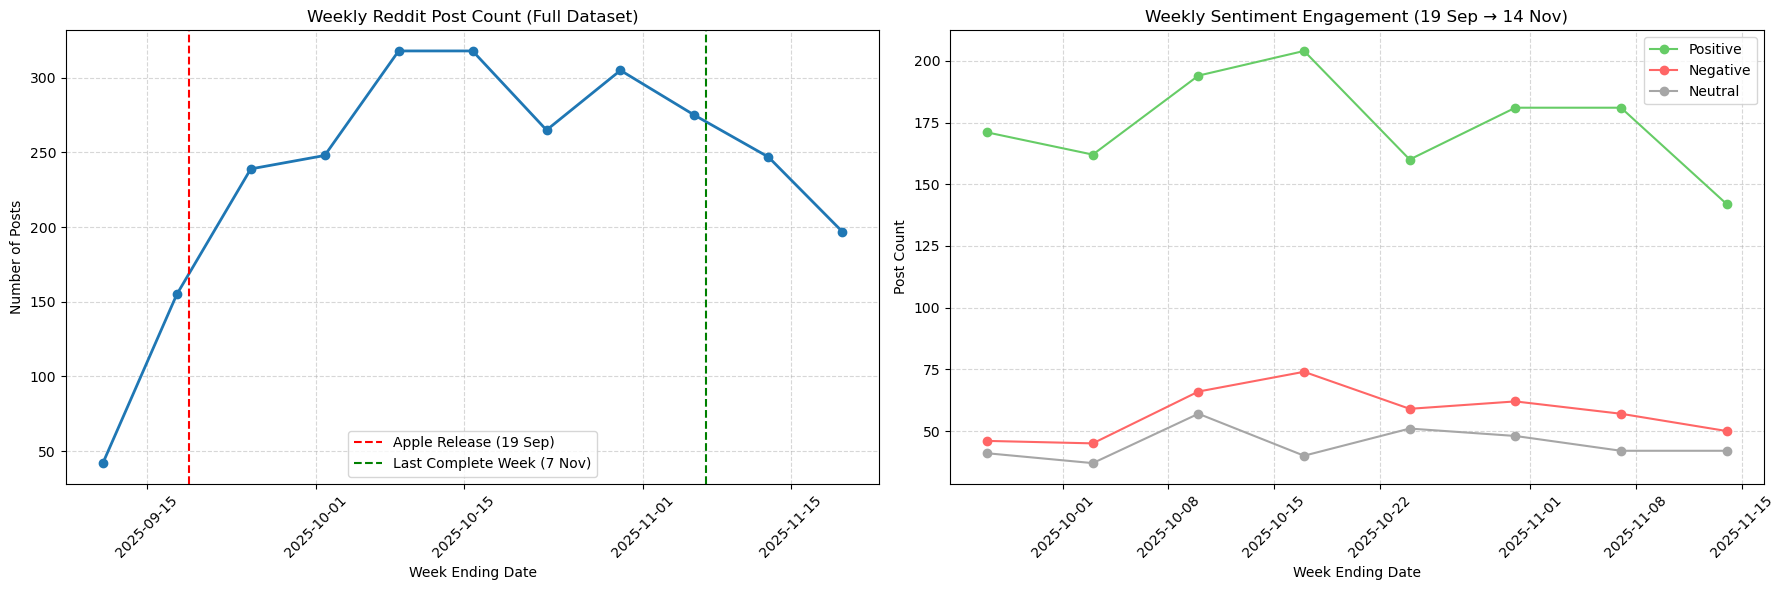

In [34]:
df['created'] = pd.to_datetime(df['created'])

# WEEKLY COUNTS FROM FIRST DATE IN DATASET (FOR PLOT 1)
start_full = df['created'].min()   # earliest date in the dataset
print("First date in dataset:", start_full)

days_since_start_full = (df['created'] - start_full).dt.days
week_idx_full = (days_since_start_full // 7) + 1

df['week_end_full'] = start_full + pd.to_timedelta(week_idx_full * 7, unit="D")

weekly_counts_full = (
    df
    .groupby('week_end_full')
    .size()
    .reset_index(name='post_count')
    .sort_values('week_end_full')
)

# WEEKLY SENTIMENT (POS/NEG/NEU) FROM 19 SEP → 14 NOV
start_date = pd.to_datetime("2025-09-19")   # Apple release
end_valid  = pd.to_datetime("2025-11-14")   # last complete week

df_range = df[(df['created'] >= start_date) & (df['created'] <= end_valid)].copy()

days_since_start = (df_range['created'] - start_date).dt.days
week_idx = (days_since_start // 7) + 1
df_range['week_end'] = start_date + pd.to_timedelta(week_idx * 7, unit="D")

sent_weekly = (
    df_range
    .groupby(['week_end', 'sentiment_label'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
    .sort_values('week_end')
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# LEFT SUBPLOT: FULL WEEKLY POST COUNT (FROM FIRST DATE)
axes[0].plot(
    weekly_counts_full['week_end_full'],
    weekly_counts_full['post_count'],
    marker='o',
    linewidth=2
)

axes[0].set_title("Weekly Reddit Post Count (Full Dataset)")
axes[0].set_xlabel("Week Ending Date")
axes[0].set_ylabel("Number of Posts")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].tick_params(axis='x', rotation=45)

axes[0].axvline(pd.to_datetime("2025-09-19"), color='red', linestyle='--',
                label="Apple Release (19 Sep)")
axes[0].axvline(pd.to_datetime("2025-11-07"), color='green', linestyle='--',
                label="Last Complete Week (7 Nov)")

axes[0].legend()

# RIGHT SUBPLOT: SENTIMENT ENGAGEMENT (COMPLETE WEEKS ONLY)
axes[1].plot(
    sent_weekly['week_end'], sent_weekly.get('positive', 0),
    marker='o', color="#66cc66", label="Positive"
)
axes[1].plot(
    sent_weekly['week_end'], sent_weekly.get('negative', 0),
    marker='o', color="#ff6666", label="Negative"
)
axes[1].plot(
    sent_weekly['week_end'], sent_weekly.get('neutral', 0),
    marker='o', color="#a6a6a6", label="Neutral"
)

axes[1].set_title("Weekly Sentiment Engagement (19 Sep → 14 Nov)")
axes[1].set_xlabel("Week Ending Date")
axes[1].set_ylabel("Post Count")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()


# LDA by Negative Posts

In [35]:
#countvectorizer makes each word into a column
vectorizer = CountVectorizer(stop_words="english", max_features=5000)

# vectorizer.transform() transforms the text into a matrix of token counts
X_counts = vectorizer.fit_transform(neg_df["full_text"]) 

# LatentDirichletAllocation is a topic model that finds topics in the data
n_topics = 5
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42) 
lda.fit(X_counts)

# returns the feature names of the data. 
terms = vectorizer.get_feature_names_out() 
print('\033[1mNegative Sentiment:\033[0m')
# Top words per topic
for idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[-10:]]
    print(f"\nTopic {idx}: {top_terms}")

Negative Sentiment:

Topic 0: ['max', 've', 'issue', 'new', 'just', 'battery', 'phone', 'pro', '17', 'iphone']

Topic 1: ['att', 'store', 'just', 'trade', 'max', 'order', 'phone', 'pro', '17', 'iphone']

Topic 2: ['got', 'issue', 'protector', 'just', 'screen', 'phone', 'iphone', '17', 'max', 'pro']

Topic 3: ['preview', 'https', 'redd', 'webp', 'width', 'apple', 'new', 'png', '17', 'iphone']

Topic 4: ['like', 'just', 'issue', 'new', 'apple', 'phone', 'max', 'pro', '17', 'iphone']


In [36]:
# Topic distribution for each negative post
topic_dist = lda.transform(X_counts)

# Index of the topic with highest probability
neg_df["topic"] = topic_dist.argmax(axis=1)
topic_name_map_neg_new = {
    0: "Battery Performance Issues",
    1: "AT&T Store, Trade-In & Ordering Experience",
    2: "Screen Complaints",
    3: 'External Content',
    4: "General Device Complaints"
}


Raw topic-level metrics:
       num_posts  total_score
topic                        
0            126         5298
1            143         6940
2             57         6727
3             17         4248
4            200         6604

Topic Engagement Metrics (Normalized):
                                            num_posts  total_score  \
topic                                                                
Battery Performance Issues                        126         5298   
AT&T Store, Trade-In & Ordering Experience        143         6940   
Screen Complaints                                  57         6727   
External Content                                   17         4248   
General Device Complaints                         200         6604   

                                            posts_norm  score_norm  \
topic                                                                
Battery Performance Issues                    0.232044    0.177684   
AT&T Store, Trade-In & 

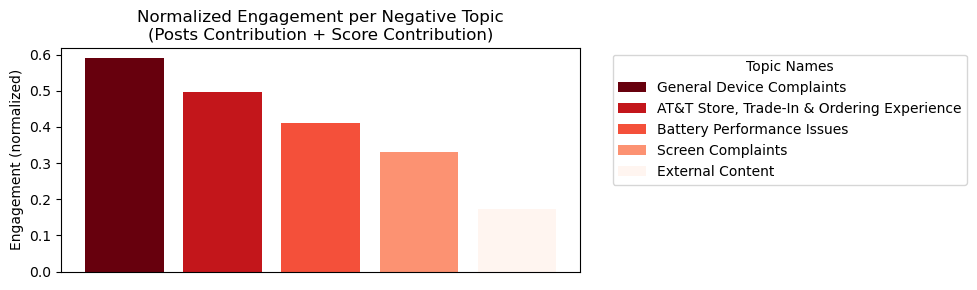

In [37]:
# Aggregate by topic
topic_metrics = (
    neg_df
    .groupby("topic")
    .agg(
        num_posts=("full_text", "size"),
        total_score=("score", "sum")
    )
)

print("\nRaw topic-level metrics:")
print(topic_metrics)

# Compute global totals
total_negative_posts = neg_df.shape[0]
total_negative_score = neg_df["score"].sum()

# Normalize by global totals
topic_metrics["posts_norm"] = topic_metrics["num_posts"] / total_negative_posts
topic_metrics["score_norm"] = topic_metrics["total_score"] / total_negative_score

# Engagement = Equal weights
topic_metrics["engagement_norm"] = (
    topic_metrics["posts_norm"] + topic_metrics["score_norm"]
)

# Add readable topic names
topic_metrics_named = topic_metrics.copy()
topic_metrics_named.index = topic_metrics_named.index.map(topic_name_map_neg_new)

print("\nTopic Engagement Metrics (Normalized):")
print(topic_metrics_named)

# Visualize Engagement
topic_metrics_sorted = topic_metrics_named.sort_values("engagement_norm", ascending=False)
df_plot = topic_metrics_sorted.reset_index()

plt.figure(figsize=(10, 3))

norm = (df_plot["engagement_norm"] - df_plot["engagement_norm"].min()) / (
    df_plot["engagement_norm"].max() - df_plot["engagement_norm"].min()
)
colors = plt.cm.Reds(norm)

bars = plt.bar(
    x=range(len(df_plot)),
    height=df_plot["engagement_norm"],
    color=colors
)

plt.title("Normalized Engagement per Negative Topic\n(Posts Contribution + Score Contribution)")
plt.xlabel("")
plt.ylabel("Engagement (normalized)")
plt.xticks([])
plt.legend(bars, df_plot["topic"], title="Topic Names", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# LDA by Positive Posts

In [38]:
# Positive-only subset
pos_df = df[df["sentiment_label"] == "positive"].copy()
pos_df = pos_df.dropna(subset=["full_text", "subreddit"])

print("Positive posts:", len(pos_df)) 

Positive posts: 1634


In [39]:
vectorizer_pos = CountVectorizer(stop_words="english", max_features=5000)
X_counts_pos = vectorizer_pos.fit_transform(pos_df["full_text"])

n_topics_pos = 5
lda_pos = LatentDirichletAllocation(n_components=n_topics_pos, random_state=42)
lda_pos.fit(X_counts_pos)

terms_pos = vectorizer_pos.get_feature_names_out()
print('\033[1mPositive Sentiment:\033[0m')
for idx, topic in enumerate(lda_pos.components_):
    top_terms = [terms_pos[i] for i in topic.argsort()[-10:]]
    print(f"\nTopic {idx}: {top_terms}")

Positive Sentiment:

Topic 0: ['app', 'issue', 'wifi', 'data', 'screen', 'new', 'just', '17', 'iphone', 'phone']

Topic 1: ['ve', 'screen', 'just', 'like', 'phone', 'max', 'case', 'iphone', '17', 'pro']

Topic 2: ['screen', 'apple', '26', 'charging', 'ios', 'issue', 'max', 'pro', 'iphone', '17']

Topic 3: ['order', 'just', 'upgrade', 'new', 'max', 'trade', 'phone', 'pro', '17', 'iphone']

Topic 4: ['apple', 'base', 'like', 'use', 'camera', 'phone', 'battery', 'pro', '17', 'iphone']


In [40]:
topic_name_map_pos = {
    0: "Connectivity, Apps & Screen Experience",
    1: "Aesthetic & Display",
    2: "iOS, Charging & Screen Performance",
    3: "Upgrade Value & Purchase Experience",
    4: "Camera Quality & Battery Performance"
}

In [41]:
topic_dist_pos = lda_pos.transform(X_counts_pos)
pos_df["topic"] = topic_dist_pos.argmax(axis=1)


Raw topic-level metrics:
       num_posts  total_score
topic                        
0             70         2990
1            550        50838
2            126         9357
3            403        23131
4            485        39079

Topic Engagement Metrics (Normalized):
                                        num_posts  total_score  posts_norm  \
topic                                                                        
Connectivity, Apps & Screen Experience         70         2990    0.042840   
Aesthetic & Display                           550        50838    0.336597   
iOS, Charging & Screen Performance            126         9357    0.077111   
Upgrade Value & Purchase Experience           403        23131    0.246634   
Camera Quality & Battery Performance          485        39079    0.296818   

                                        score_norm  engagement_norm  
topic                                                                
Connectivity, Apps & Screen Experienc

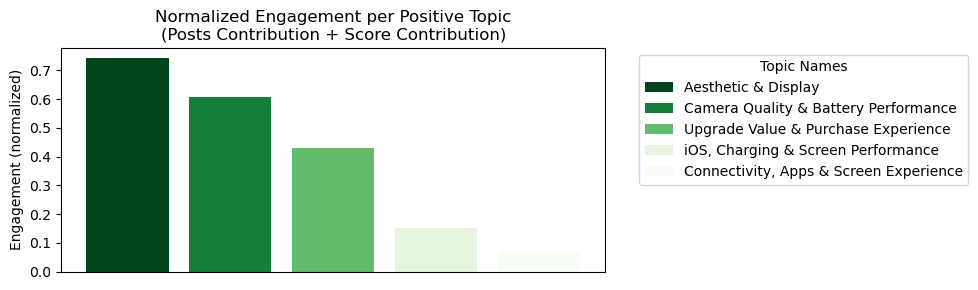

In [42]:
# Aggregate by topic
pos_topic_metrics = (
    pos_df
    .groupby("topic")
    .agg(
        num_posts=("full_text", "size"),
        total_score=("score", "sum")
    )
)

print("\nRaw topic-level metrics:")
print(pos_topic_metrics)

# Compute global totals
total_positive_posts = pos_df.shape[0]
total_positive_score = pos_df["score"].sum()

# Normalize by global totals
pos_topic_metrics["posts_norm"] = pos_topic_metrics["num_posts"] / total_positive_posts
pos_topic_metrics["score_norm"] = pos_topic_metrics["total_score"] / total_positive_score

# Engagement = Equal weights
pos_topic_metrics["engagement_norm"] = (
    pos_topic_metrics["posts_norm"] + pos_topic_metrics["score_norm"]
)

# Add readable topic names
topic_metrics_named_pos = pos_topic_metrics.copy()
topic_metrics_named_pos.index = topic_metrics_named_pos.index.map(topic_name_map_pos)

print("\nTopic Engagement Metrics (Normalized):")
print(topic_metrics_named_pos)

# Visualize Engagement
topic_metrics_sorted_pos = topic_metrics_named_pos.sort_values("engagement_norm", ascending=False)
df_plot_pos = topic_metrics_sorted_pos.reset_index()

plt.figure(figsize=(10, 3))

norm = (df_plot_pos["engagement_norm"] - df_plot_pos["engagement_norm"].min()) / (
    df_plot_pos["engagement_norm"].max() - df_plot_pos["engagement_norm"].min()
)
colors = plt.cm.Greens(norm)

bars = plt.bar(
    x=range(len(df_plot_pos)),
    height=df_plot_pos["engagement_norm"],
    color=colors
)

plt.title("Normalized Engagement per Positive Topic\n(Posts Contribution + Score Contribution)")
plt.xlabel("")
plt.ylabel("Engagement (normalized)")
plt.xticks([])
plt.legend(bars, df_plot_pos["topic"], title="Topic Names", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


# Positive Sentiment - Topic 1 Word Cloud (Aesthetic & Display)

In [43]:
# COMMON STOPWORDS + HELPER FUNCTION
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
import numpy as np

# Custom domain-specific stopwords
custom_words = {
    "iphone", "iphones", "iphone17", "iphone 17",
    "pro", "max", "promax", "apple", "phone", "17", "https"
}

# Merge with English stopwords
all_stops = list(ENGLISH_STOP_WORDS.union(custom_words))

def get_engagement_weighted_ngram_freq(texts, scores, ngram_range):
    """
    Engagement-weighted n-gram frequencies.

    Engagement per post = (1/total_posts) + (score_i / total_score)

    Weighted term frequency = sum(term_count_in_post * engagement_i)
    """
    texts = list(texts)
    scores = np.asarray(scores, dtype=float)

    # Clip negative scores
    scores = np.clip(scores, a_min=0, a_max=None)

    total_posts = len(texts)
    if total_posts == 0:
        return {}

    total_score = scores.sum()

    # post_share (equal for all)
    post_share = np.full_like(scores, 1.0 / total_posts, dtype=float)

    # score_share (relative to score)
    if total_score > 0:
        score_share = scores / total_score
    else:
        score_share = np.zeros_like(scores)

    engagement = post_share + score_share  # weight per post

    # CountVectorizer to get term matrix
    vec = CountVectorizer(ngram_range=ngram_range, stop_words=all_stops)
    X = vec.fit_transform(texts)

    # Weighted term frequencies
    freqs = X.T.dot(engagement).ravel()
    vocab = vec.get_feature_names_out()

    return dict(zip(vocab, freqs))


Positive Topic 1 posts: 550

Engagement by Subreddit for Positive Topic 1:
               num_posts  total_score  engagement
subreddit                                        
iphone               162        29367       29529
iPhone17Pro          212        13387       13599
iphone17              90         3541        3631
iPhoneography         29         3543        3572
patinaproud           44          822         866
iOSsetups             10          169         179
ATT                    3            9          12


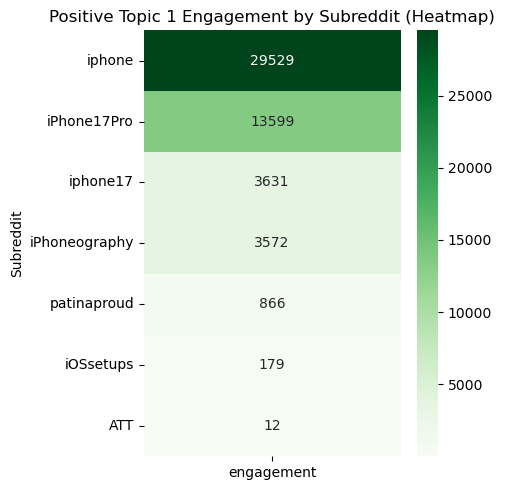

In [44]:
pos_topic4_df = pos_df[pos_df["topic"] == 1].copy()

print("Positive Topic 1 posts:", len(pos_topic4_df))

# 2. AGGREGATE BY SUBREDDIT
subreddit_engagement = (
    pos_topic4_df
    .groupby("subreddit")
    .agg(
        num_posts=("full_text", "size"),
        total_score=("score", "sum")
    )
)

# Engagement metric
subreddit_engagement["engagement"] = (
    subreddit_engagement["num_posts"] + subreddit_engagement["total_score"]
)

# Sort by engagement
subreddit_engagement = subreddit_engagement.sort_values("engagement", ascending=False)

print("\nEngagement by Subreddit for Positive Topic 1:")
print(subreddit_engagement)

# Convert to heatmap-ready 2D table
heatmap_data = subreddit_engagement[["engagement"]]

plt.figure(figsize=(5, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Greens",     # green heatmap for positive topics
    cbar=True
)

plt.title("Positive Topic 1 Engagement by Subreddit (Heatmap)")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()


Positive Topic 1 posts from selected subreddits: 374


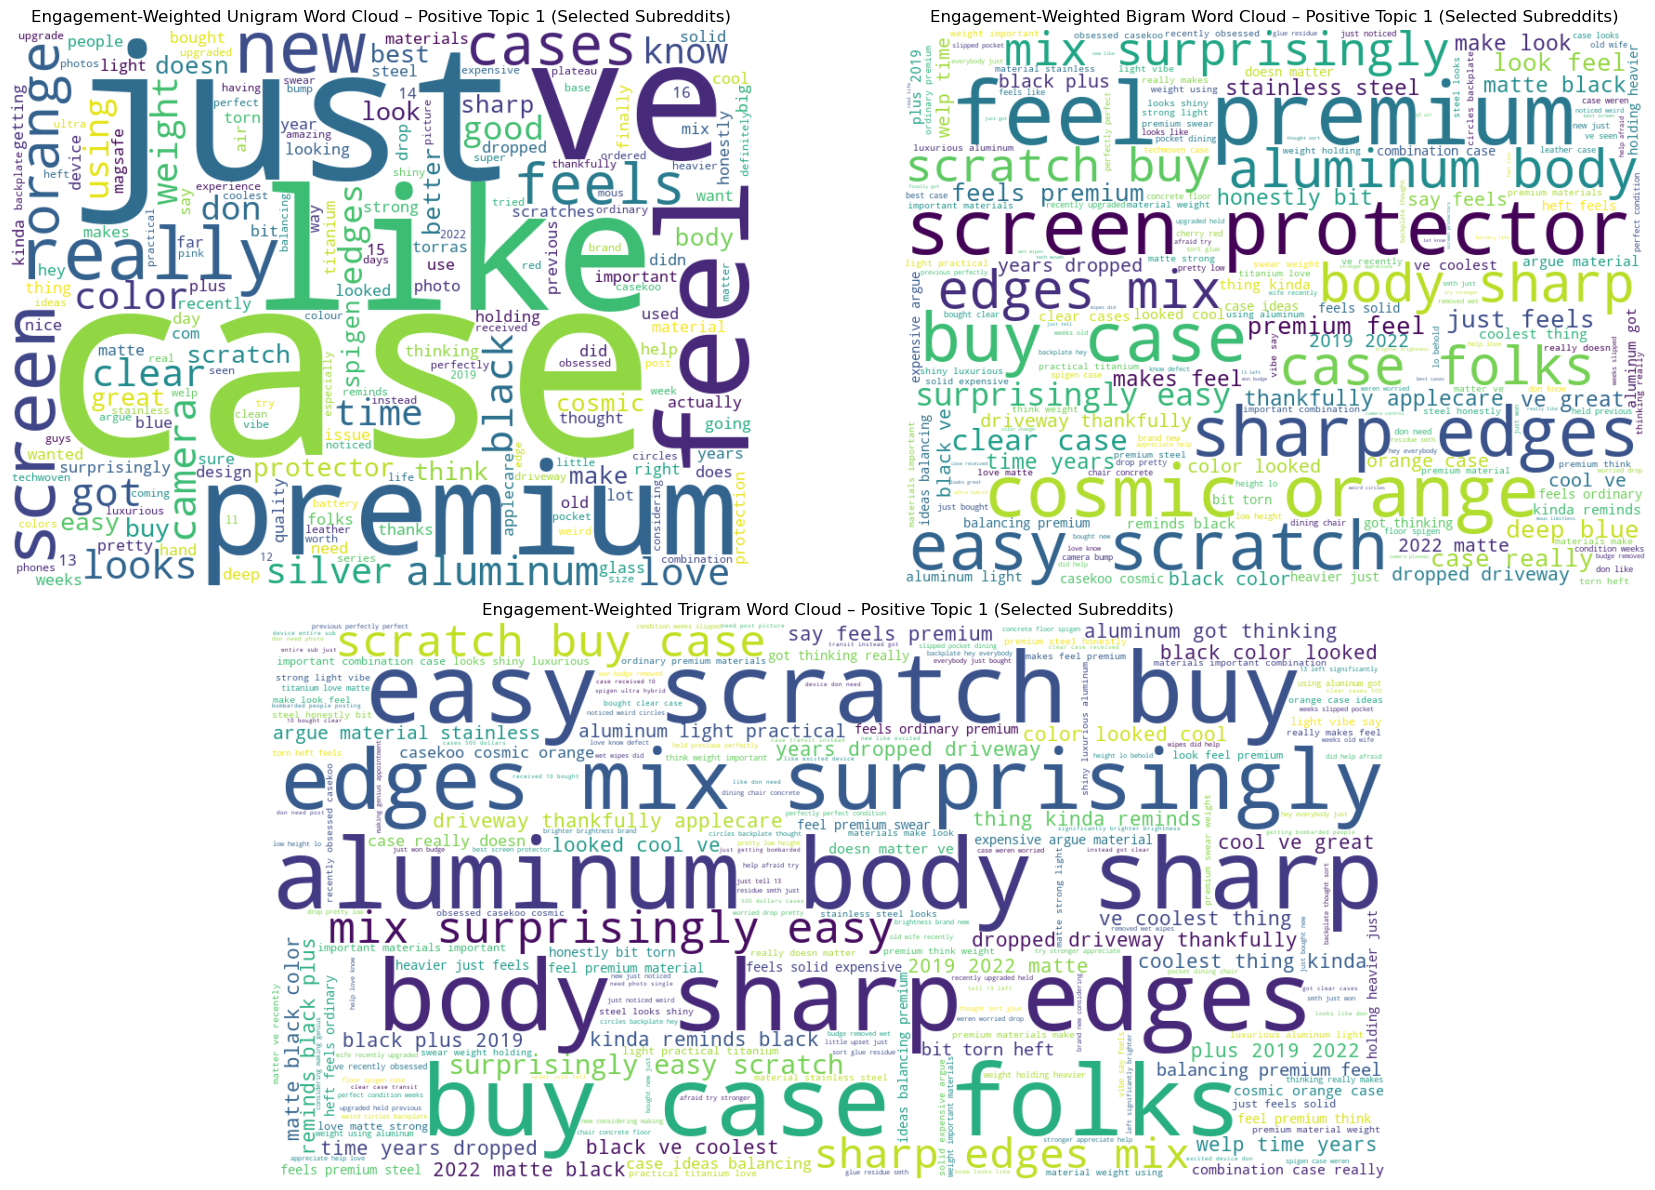

In [45]:
# FILTER TOPIC 1 + SELECTED SUBREDDITS
selected_subs = ["iphone", "iphone17pro"]
sub_lower = [s.lower() for s in selected_subs]

TOPIC_NUM = 1
subset_df = pos_df[
    (pos_df["topic"] == TOPIC_NUM) &
    (pos_df["subreddit"].str.lower().isin(sub_lower))
].copy()

print(f"Positive Topic {TOPIC_NUM} posts from selected subreddits: {len(subset_df)}")

if subset_df.empty:
    raise ValueError("No posts found for Positive Topic 1 in selected subreddits.")

texts  = subset_df["full_text"].tolist()
scores = subset_df["score"].values

# ==== ENGAGEMENT-WEIGHTED UNIGRAM, BIGRAM, TRIGRAM FREQUENCIES ====
unigrams = get_engagement_weighted_ngram_freq(texts, scores, (1, 1))
bigrams  = get_engagement_weighted_ngram_freq(texts, scores, (2, 2))
trigrams = get_engagement_weighted_ngram_freq(texts, scores, (3, 3))

# ==== PLOT WORDCLOUDS ====
plt.figure(figsize=(18, 12))

# ---- Unigram ----
plt.subplot(2, 2, 1)
wc_uni = WordCloud(
    width=800, height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(unigrams)
plt.imshow(wc_uni, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Unigram Word Cloud – Positive Topic 1 (Selected Subreddits)")

# ---- Bigram ----
plt.subplot(2, 2, 2)
wc_bi = WordCloud(
    width=800, height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(bigrams)
plt.imshow(wc_bi, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Bigram Word Cloud – Positive Topic 1 (Selected Subreddits)")

# ---- Trigram ----
plt.subplot(2, 1, 2)
wc_tri = WordCloud(
    width=1200, height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(trigrams)
plt.imshow(wc_tri, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Trigram Word Cloud – Positive Topic 1 (Selected Subreddits)")

plt.tight_layout()
plt.show()


# Positive Sentiment - Topic 4 Word Cloud (Camera Quality & Battery Performance)

Positive Topic 4 posts: 485

Engagement by Subreddit for Positive Topic 4:
               num_posts  total_score  engagement
subreddit                                        
iphone               122        21309       21431
iPhone17Pro          124         6408        6532
iPhoneography         60         6111        6171
iphone17             178         5246        5424
iOSsetups              1            5           6


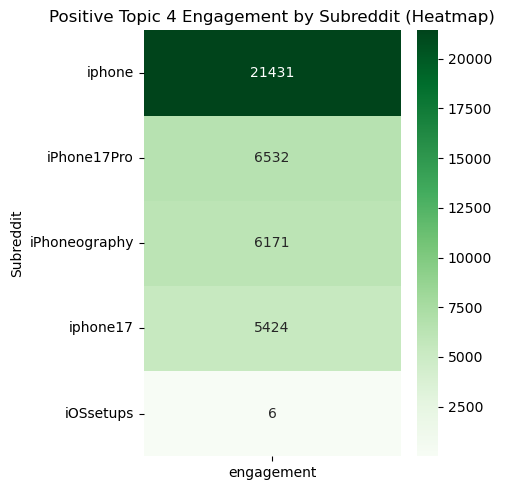

In [46]:
# FILTER: POSITIVE TOPIC 4
pos_topic4_df = pos_df[pos_df["topic"] == 4].copy()

print("Positive Topic 4 posts:", len(pos_topic4_df))

# 2. AGGREGATE BY SUBREDDIT
subreddit_engagement = (
    pos_topic4_df
    .groupby("subreddit")
    .agg(
        num_posts=("full_text", "size"),
        total_score=("score", "sum")
    )
)

# Engagement metric
subreddit_engagement["engagement"] = (
    subreddit_engagement["num_posts"] + subreddit_engagement["total_score"]
)

# Sort by engagement (highest first)
subreddit_engagement = subreddit_engagement.sort_values("engagement", ascending=False)

print("\nEngagement by Subreddit for Positive Topic 4:")
print(subreddit_engagement)

# Convert to heatmap-ready 2D table
heatmap_data = subreddit_engagement[["engagement"]]

# PLOT HEATMAP
plt.figure(figsize=(5, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Greens",     # green palette for positive sentiment
    cbar=True
)

plt.title("Positive Topic 4 Engagement by Subreddit (Heatmap)")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()


Positive Topic 4 posts from selected subreddits: 306


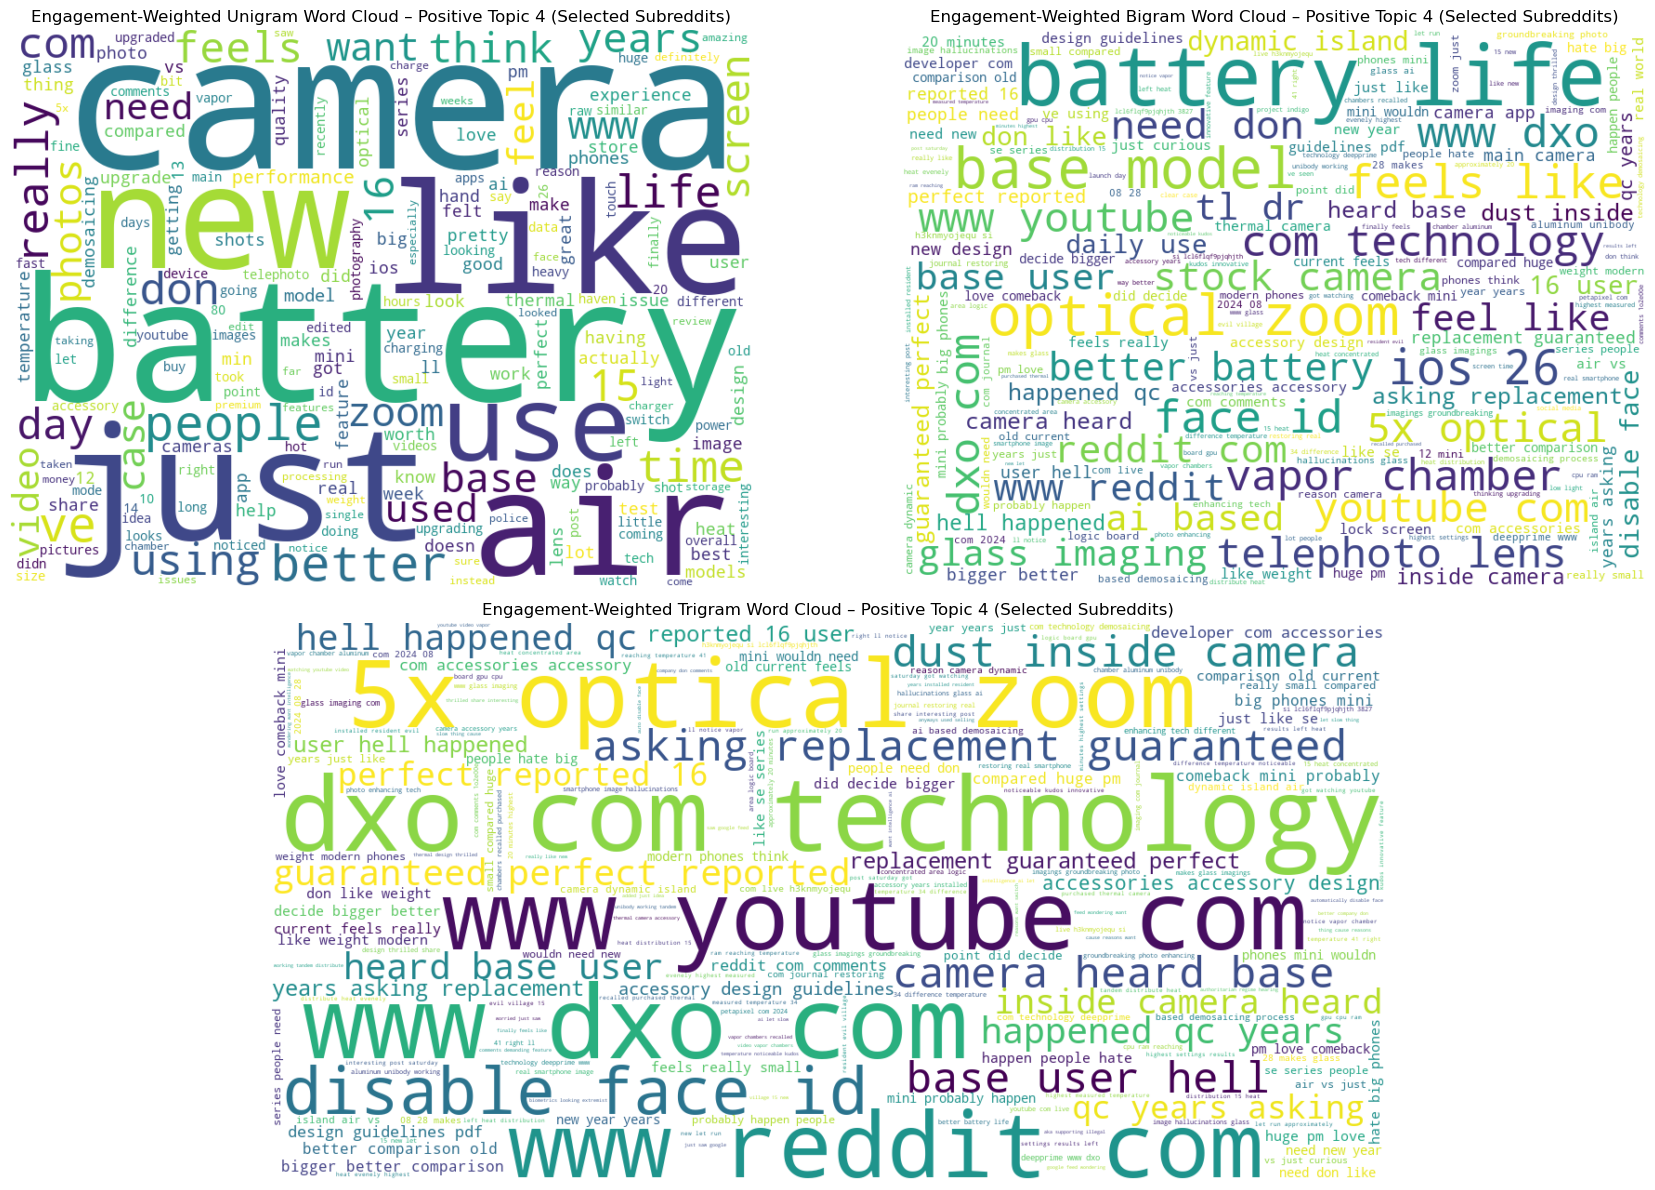

In [47]:
# FILTER TOPIC 4 + SELECTED SUBREDDITS
selected_subs = ["iphone", "iPhone17Pro", "iPhoneography", "iphone 17"]
sub_lower = [s.lower() for s in selected_subs]

TOPIC_NUM = 4
subset_df = pos_df[
    (pos_df["topic"] == TOPIC_NUM) &
    (pos_df["subreddit"].str.lower().isin(sub_lower))
].copy()

print(f"Positive Topic {TOPIC_NUM} posts from selected subreddits: {len(subset_df)}")

if subset_df.empty:
    raise ValueError("No posts found for Positive Topic 4 in selected subreddits.")

texts  = subset_df["full_text"].tolist()
scores = subset_df["score"].values

# ENGAGEMENT-WEIGHTED UNIGRAM, BIGRAM, TRIGRAM FREQUENCIES
unigrams = get_engagement_weighted_ngram_freq(texts, scores, (1, 1))
bigrams  = get_engagement_weighted_ngram_freq(texts, scores, (2, 2))
trigrams = get_engagement_weighted_ngram_freq(texts, scores, (3, 3))

# ==== PLOT WORDCLOUDS ====
plt.figure(figsize=(18, 12))

# ---- Unigram ----
plt.subplot(2, 2, 1)
wc_uni = WordCloud(
    width=800, height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(unigrams)
plt.imshow(wc_uni, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Unigram Word Cloud – Positive Topic 4 (Selected Subreddits)")

# ---- Bigram ----
plt.subplot(2, 2, 2)
wc_bi = WordCloud(
    width=800, height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(bigrams)
plt.imshow(wc_bi, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Bigram Word Cloud – Positive Topic 4 (Selected Subreddits)")

# ---- Trigram ----
plt.subplot(2, 1, 2)
wc_tri = WordCloud(
    width=1200, height=600,
    background_color="white",
    collocations=False
).generate_from_frequencies(trigrams)
plt.imshow(wc_tri, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Trigram Word Cloud – Positive Topic 4 (Selected Subreddits)")

plt.tight_layout()
plt.show()


# RELATIVE PERCENTAGES: POSITIVE TOPIC 4 (Battery Performance) vs NEGATIVE TOPIC 0 (Battery Performance Issues)

In [48]:
# POSITIVE TOPIC 4
pos_topic4 = pos_df[pos_df["topic"] == 4]
num_posts_pos = len(pos_topic4)
total_score_pos = pos_topic4["score"].clip(lower=0).sum()

# NEGATIVE TOPIC 0
neg_topic0 = neg_df[neg_df["topic"] == 0]
num_posts_neg = len(neg_topic0)
total_score_neg = neg_topic0["score"].clip(lower=0).sum()

# GLOBAL TOTALS
total_posts = num_posts_pos + num_posts_neg
total_score = total_score_pos + total_score_neg

# AVOID DIVISION BY ZERO
if total_posts == 0 or total_score == 0:
    raise ValueError("No posts or no scores to compute engagement.")

# Normalized Engagement 
eng_pos = (num_posts_pos / total_posts) + (total_score_pos / total_score)
eng_neg = (num_posts_neg / total_posts) + (total_score_neg / total_score)

# NORMALIZE TO PERCENT
total_eng = eng_pos + eng_neg
pos_pct = eng_pos / total_eng * 100
neg_pct = eng_neg / total_eng * 100

print("Relative Engagement Between Topics (same logic as sentiment_metrics):")
print(f"Positive Topic 4 Engagement Share: {pos_pct:.2f}%")
print(f"Negative Topic 0 Engagement Share: {neg_pct:.2f}%")


Relative Engagement Between Topics (same logic as sentiment_metrics):
Positive Topic 4 Engagement Share: 83.72%
Negative Topic 0 Engagement Share: 16.28%


# Negative Sentiment - Topics 4 Word Cloud (General Device Complaints)

Negative Topic 4 posts: 200

Engagement by Subreddit for Negative Topic 4:
               num_posts  total_score  engagement
subreddit                                        
iphone                98         4594        4692
iPhone17Pro           45         1329        1374
iphone17              38          405         443
iPhoneography          6          204         210
ATT                   10           59          69
patinaproud            2            9          11
iOSsetups              1            4           5


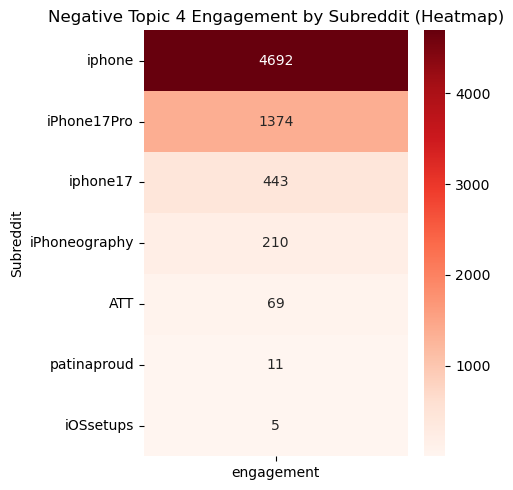

In [49]:
# FILTER NEGATIVE TOPIC 4
neg_topic4_df = neg_df[neg_df["topic"] == 4].copy()
print("Negative Topic 4 posts:", len(neg_topic4_df))

# AGGREGATE BY SUBREDDIT
subreddit_engagement = (
    neg_topic4_df
    .groupby("subreddit")
    .agg(
        num_posts=("full_text", "size"),
        total_score=("score", "sum")
    )
)

# Engagement metric 
subreddit_engagement["engagement"] = (
    subreddit_engagement["num_posts"] + subreddit_engagement["total_score"]
)

# Sort by engagement (highest first)
subreddit_engagement = subreddit_engagement.sort_values("engagement", ascending=False)

print("\nEngagement by Subreddit for Negative Topic 4:")
print(subreddit_engagement)

# Convert to heatmap-friendly format (2D)
heatmap_data = subreddit_engagement[["engagement"]]

plt.figure(figsize=(5,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="Reds", 
    cbar=True
)

plt.title("Negative Topic 4 Engagement by Subreddit (Heatmap)")
plt.ylabel("Subreddit")
plt.tight_layout()
plt.show()


Negative posts in r/iphone: 212
Negative Topic 4 posts from r/iphone: 9


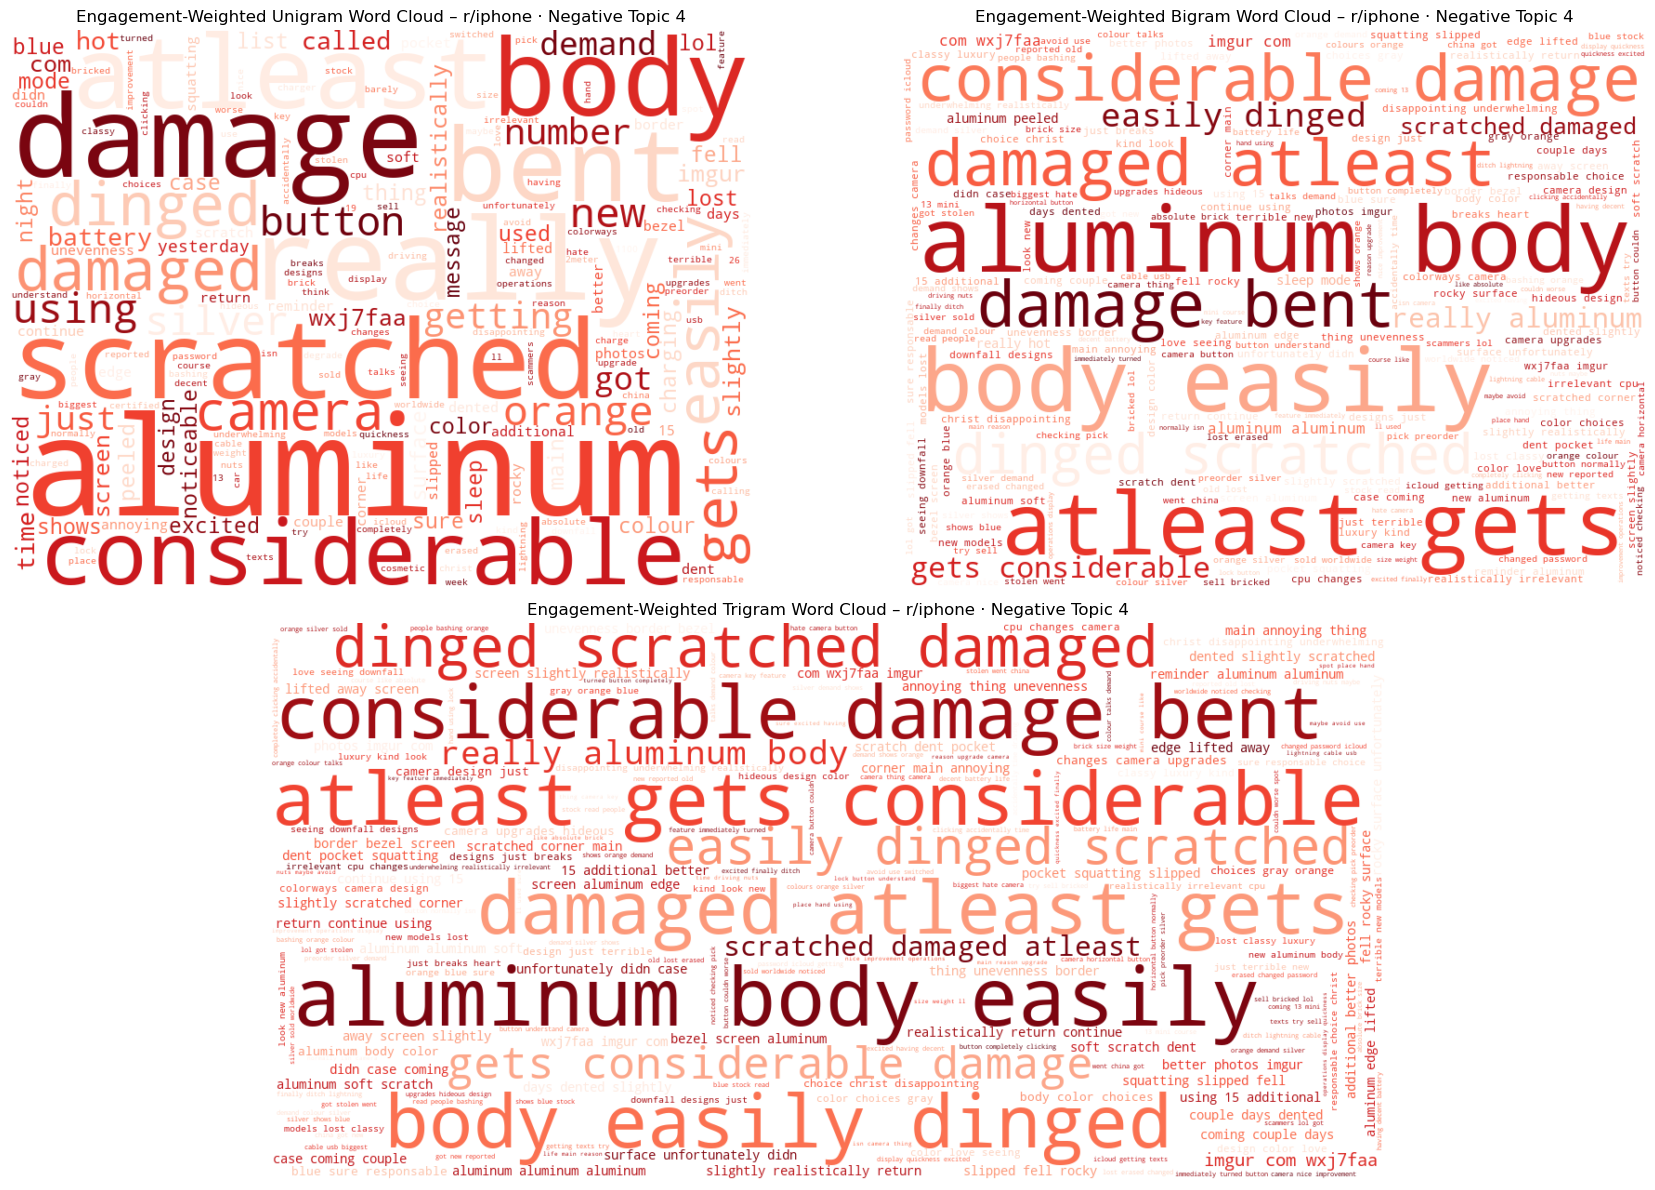

In [50]:

# FILTER: NEGATIVE + r/iphone
neg_df_iphone = df[
    (df["sentiment_label"] == "negative") &
    (df["subreddit"].str.lower() == "iphone")
].copy()

neg_df_iphone = neg_df_iphone.dropna(subset=["full_text"])
print("Negative posts in r/iphone:", len(neg_df_iphone))

# TOPIC MODELING (5 topics)
vectorizer = CountVectorizer(stop_words="english", max_features=5000)
X_counts = vectorizer.fit_transform(neg_df_iphone["full_text"])

lda = LatentDirichletAllocation(n_components=5, random_state=42)
topic_dist = lda.fit_transform(X_counts)
neg_df_iphone["topic"] = topic_dist.argmax(axis=1)

# FILTER TOPIC 4
TOPIC_NUM = 4
topic_df = neg_df_iphone[neg_df_iphone["topic"] == TOPIC_NUM].copy()

print(f"Negative Topic {TOPIC_NUM} posts from r/iphone:", len(topic_df))
if topic_df.empty:
    raise ValueError("No posts found for Negative Topic 4 in r/iphone.")

texts  = topic_df["full_text"].tolist()
scores = topic_df["score"].values

# ENGAGEMENT-WEIGHTED FREQUENCIES
unigram_freq = get_engagement_weighted_ngram_freq(texts, scores, (1, 1))
bigram_freq  = get_engagement_weighted_ngram_freq(texts, scores, (2, 2))
trigram_freq = get_engagement_weighted_ngram_freq(texts, scores, (3, 3))

# ==============================
# WORDCLOUD PLOTS (RED)
# ==============================
plt.figure(figsize=(18, 12))

# Unigram
plt.subplot(2, 2, 1)
wc_uni = WordCloud(
    width=800, height=600,
    background_color="white",
    colormap="Reds",
    collocations=False
).generate_from_frequencies(unigram_freq)
plt.imshow(wc_uni, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Unigram Word Cloud – r/iphone · Negative Topic 4")

# Bigram
plt.subplot(2, 2, 2)
wc_bi = WordCloud(
    width=800, height=600,
    background_color="white",
    colormap="Reds",
    collocations=False
).generate_from_frequencies(bigram_freq)
plt.imshow(wc_bi, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Bigram Word Cloud – r/iphone · Negative Topic 4")

# Trigram
plt.subplot(2, 1, 2)
wc_tri = WordCloud(
    width=1200, height=600,
    background_color="white",
    colormap="Reds",
    collocations=False
).generate_from_frequencies(trigram_freq)
plt.imshow(wc_tri, interpolation="bilinear")
plt.axis("off")
plt.title("Engagement-Weighted Trigram Word Cloud – r/iphone · Negative Topic 4")

plt.tight_layout()
plt.show()